<a href="https://colab.research.google.com/github/uk-zash/Machine-Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression: The Line of Best Fit

Linear Regression is a fundamental supervised learning algorithm used for predictive analysis. At its core, Machine Learning, in this context, aims to find a mathematical relationship between input features (independent variables) and a target output (dependent variable). If you have data on house sizes (`X`) and their corresponding prices (`y`), Linear Regression attempts to draw a straight line (or a hyperplane in higher dimensions) that best captures this relationship. The goal is to model the linear relationship between a dependent variable and one or more independent variables.

This notebook will delve into the underlying mechanism that allows models like Linear Regression to 'learn' this line: **Gradient Descent**.

## The Core Idea: Gradient Descent Loop

### Gradient descent basically runs this loop:

1. Make predictions.
2. Measure error.
3. Calculate gradients.
4. Update parameters.
5. Repeat.

Or mathematically:

$w, b$

$\,\downarrow$

$\hat{y} = wx+b$

$\,\downarrow$

MSE

$\,\downarrow$

$\frac{\partial L}{\partial w}$, $\frac{\partial L}{\partial b}$

$\,\downarrow$

$w_{new}, b_{new}$

$\,\downarrow$

repeat.

In [7]:
x = [1 , 2 ,3]
y = [3 , 5 , 7]

w = 0
b = 0

learning_rates = 0.01
epochs = 100

In [8]:
n = len(x)
n

3

In [9]:
for epoch in range(epochs):

  # 1. Forward Pass: Make predictions using current weights (w) and bias (b)
  prediction = [w * xi + b for xi in x]

  # Print current predictions (optional, for debugging/observation)
  print("Prediction --->" , prediction)

  # 2. Calculate Gradients: Determine how much w and b need to change
  # The gradient for w (dw) is the derivative of the loss function with respect to w.
  # The gradient for b (db) is the derivative of the loss function with respect to b.
  # For Mean Squared Error (MSE), the derivatives are derived from: Loss = (1/n) * sum((y_pred - y)^2)
  # dLoss/dw = (2/n) * sum((y_pred - y) * x)
  # dLoss/db = (2/n) * sum(y_pred - y)

  dw = (2/n) * sum(
        (prediction[i] - y[i]) * x[i]
        for i in range(n)
    )
  print("Graident W ----> ", dw)

  db = (2/n)* sum((prediction[i] - y[i] for i in range(n)))
  print("Gradient b ----->" , db)

  # 3. Update Parameters (Gradient Descent Step):
  # Adjust w and b in the direction opposite to the gradient
  # scaled by the learning rate to minimize the loss.
  w = w - learning_rates * dw
  b = b - learning_rates * db

  # Print updated weights and bias (optional)
  print("Updated weights -----> " , (w , b))

  # Optional: You might want to calculate and print the loss here as well
  # loss = sum((prediction[i] - y[i])**2 for i in range(n)) / n
  # print(f"Loss: {loss}")

Prediction ---> [0, 0, 0]
Graident W ---->  -22.666666666666664
Gradient b -----> -10.0
Updated weights ----->  (0.22666666666666666, 0.1)
Prediction ---> [0.32666666666666666, 0.5533333333333333, 0.7799999999999999]
Graident W ---->  -20.15111111111111
Gradient b -----> -8.893333333333333
Updated weights ----->  (0.42817777777777777, 0.18893333333333334)
Prediction ---> [0.6171111111111112, 1.045288888888889, 1.4734666666666667]
Graident W ---->  -17.914607407407406
Gradient b -----> -7.909422222222222
Updated weights ----->  (0.6073238518518518, 0.2680275555555556)
Prediction ---> [0.8753514074074074, 1.4826752592592591, 2.089999111111111]
Graident W ---->  -15.926200493827162
Gradient b -----> -7.034649481481481
Updated weights ----->  (0.7665858567901234, 0.3383740503703704)
Prediction ---> [1.1049599071604939, 1.8715457639506172, 2.6381316207407406]
Graident W ---->  -14.158369135144035
Gradient b -----> -6.2569084720987656
Updated weights ----->  (0.9081695481415637, 0.4009431350

In [10]:
## NumPy Version: Optimized Gradient Descent

## While implementing Gradient Descent from scratch helps with understanding, in practice, libraries like NumPy provide optimized ways to perform these calculations, especially for vectorized operations. This significantly speeds up computation for larger datasets.

In [11]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])
y = np.array([3.0, 5.0, 7.0])

w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 1000

n = len(x)

for epoch in range(epochs):

    # Forward pass: Calculate predicted y values
    y_pred = w * x + b

    # Calculate Mean Squared Error (MSE) loss
    loss = np.mean((y_pred - y) ** 2)

    # Calculate Gradients using vectorized operations
    # dw = (2/n) * sum((y_pred - y) * x)
    # db = (2/n) * sum(y_pred - y)
    dw = (2 / n) * np.sum((y_pred - y) * x)
    db = (2 / n) * np.sum(y_pred - y)

    # Update parameters (w and b) using the gradients and learning rate
    w -= learning_rate * dw
    b -= learning_rate * db

    # Print progress every 100 epochs
    if epoch % 100 == 0:
        print(
            f"epoch={epoch}, "
            f"loss={loss:.6f}, "
            f"w={w:.4f}, "
            f"b={b:.4f}"
        )

print("\nLearned parameters:")
print("w =", w)
print("b =", b)

epoch=0, loss=27.666667, w=0.2267, b=0.1000
epoch=100, loss=0.000899, w=2.0347, b=0.9210
epoch=200, loss=0.000556, w=2.0273, b=0.9379
epoch=300, loss=0.000343, w=2.0215, b=0.9512
epoch=400, loss=0.000212, w=2.0169, b=0.9616
epoch=500, loss=0.000131, w=2.0133, b=0.9698
epoch=600, loss=0.000081, w=2.0104, b=0.9763
epoch=700, loss=0.000050, w=2.0082, b=0.9814
epoch=800, loss=0.000031, w=2.0064, b=0.9854
epoch=900, loss=0.000019, w=2.0051, b=0.9885

Learned parameters:
w = 2.003991621708228
b = 0.9909261056278122


## The Four Fundamental Lines of Gradient Descent

```markdown
These four lines contain almost the entire learning algorithm:

1. Make predictions.
```python
y_pred = w * x + b
```

2. Measure how wrong they are.

```python
loss = np.mean((y_pred - y) ** 2)
```

3. Figure out which direction w and b should move.

```python
dw = (2 / n) * np.sum((y_pred - y) * x)
db = (2 / n) * np.sum(y_pred - y)
```

4. Move them.

```python
w -= learning_rate * dw
b -= learning_rate * db
```
That's gradient descent.
```

## What is an Epoch?

Suppose there are 100 houses in your training dataset.

The model goes through those 100 houses and updates/learns from them.

One complete pass through the training dataset is called an **epoch**.

In [12]:
#The `epochs` parameter defines how many complete passes the learning algorithm will make over the entire training dataset. In our example, `epochs = 1000` means the learning process will repeat 1000 times, allowing the model to progressively refine its weights and bias.

## Why are Weights Initialized Randomly in Bigger ML Models?

In our tiny linear regression example, starting from:

w = 0
b = 0

is perfectly fine.

But neural networks often initialize weights to small random values.

Why?

Because if many neurons begin with exactly the same values, they can behave identically.

Random initialization breaks that symmetry.

You'll encounter this later when studying neural networks.

## Handling Multiple Features

What if there are multiple features?

Real house prices don't depend only on size.

Maybe we have:

size
bedrooms
bathrooms
age
distance to downtown

Then our equation becomes:

$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + w_5 x_5 + b$

For example:

$\text{Price} = w_1 (\text{Size}) + w_2 (\text{Bedrooms}) + w_3 (\text{Age}) + b$

Every feature gets its own weight.

## Interpreting Weights

What does each weight mean?

Suppose the trained equation is:

$Price = 200(\text{Size}) + 25000(\text{Bedrooms}) - 1000(\text{Age}) + 50000$

Then roughly:

Size weight
$w_1 = 200$

One additional unit of size is associated with +200 in predicted price, holding other features fixed.

Bedroom weight
$w_2 = 25000$

One additional bedroom changes prediction by approximately +25,000.

Age weight
$w_3 = -1000$

One additional year changes predicted price by approximately -1,000.

Negative weights are perfectly valid.

## Vector Notation for Multiple Features

When there are many features, instead of writing:

$w_1 x_1 + w_2 x_2 + w_3 x_3 + \dots$

we write:

$\hat{y} = w^T x + b$


For example:

$x = \begin{pmatrix} 1000 \\ 3 \\ 10 \end{pmatrix}$


and:

$w = \begin{pmatrix} 200 \\ 25000 \\ -1000 \end{pmatrix}$


Then:

$w^T x$

means:

$200(1000)+25000(3)+(-1000)(10)$

This is why linear algebra becomes so important in machine learning.

## Three kinds of gradient descent

When your dataset becomes large, there are several ways to calculate the gradient.

### 1. Batch Gradient Descent

Use the entire training dataset before one update.

100,000 examples
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\downarrow$
calculate gradient
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\downarrow$
update weights once

Stable, but potentially expensive.



### 2. Stochastic Gradient Descent

Use one example.

example 1 → update
example 2 → update
example 3 → update
...

Called SGD.

It is fast but noisy. This means the updates to the model parameters are more erratic and less stable because they are based on a single data point's gradient, which can vary significantly from one example to the next.



### 3. Mini-batch Gradient Descent

Use a small group:

32 examples → update
32 examples → update
32 examples → update

Or:

64
128
256

This is extremely common in deep learning.

When people casually say "SGD", they sometimes mean mini-batch SGD too.

## AI != Gradient Descent

It's important to remember that Artificial Intelligence (AI) and Machine Learning (ML) encompass a vast range of concepts and techniques. Gradient Descent is a fundamental optimization algorithm crucial for training many machine learning models, especially neural networks, but it is just *one tool* within the broader field. AI involves far more than just optimizing parameters with gradient descent; it includes data representation, model architectures, ethical considerations, and complex decision-making processes.

## Training vs. Inference

Another important distinction: training vs inference

Once the model has learned:

$w=2$
$b=1$

and you ask:

What is y for x=10?

it calculates:

$2(10)+1=21$

No gradient descent is required.

That's called:

**inference**


So:

**Training**

Learn w and b.

**Inference**

Use the learned w and b.

## Training Data vs. Unseen Data (Generalization)

Suppose our model perfectly memorizes its training examples.

That doesn't necessarily mean it's good.

We care about whether it works on data it has never seen before.

For example:

Training:

500 sqft
700 sqft
900 sqft
1100 sqft

Then test it on:

800 sqft

A useful model should make a reasonable prediction.

This ability is called:

**generalization**


And generalization is really what machine learning is about.

Not simply minimizing training error.

## Manual Gradient Descent Implementation

In [13]:
x = [1, 2, 3]
y = [3, 5, 7]

w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 1000

# Get the number of training examples
n = len(x)

for epoch in range(epochs):

    # ---------- Forward pass ----------
    # Calculate predictions for all x values using current w and b
    predictions = []
    for xi in x:
        prediction = w * xi + b
        predictions.append(prediction)

    # ---------- Calculate Loss (Mean Squared Error) ----------
    # Sum of squared differences between actual (y) and predicted values
    total_squared_error = 0
    for actual, predicted in zip(y, predictions):
        error = predicted - actual
        total_squared_error += error ** 2

    # Average the squared error
    mse = total_squared_error / n

    # ---------- Calculate Gradients ----------
    # Initialize gradients for w and b
    dw = 0
    db = 0

    # Iterate through each example to accumulate gradients
    for xi, actual, predicted in zip(
        x, y, predictions
    ):
        error = predicted - actual # (y_pred - y)

        # Gradient for w: (y_pred - y) * x
        dw += error * xi
        # Gradient for b: (y_pred - y)
        db += error

    # Average the gradients over all examples
    dw = (2 / n) * dw
    db = (2 / n) * db

    # ---------- Gradient Descent Update ----------
    # Adjust w and b in the direction that reduces the loss
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # ---------- Show Progress (optional) ----------
    # Print status every 100 epochs
    if epoch % 100 == 0:
        print(
            "epoch:", epoch,
            "loss:", mse,
            "w:", w,
            "b:", b
        )

print()
print("Final model:")
print(f"y = {w:.3f}x + {b:.3f}")

epoch: 0 loss: 27.666666666666668 w: 0.22666666666666666 b: 0.1
epoch: 100 loss: 0.0008990740646563003 w: 2.0347272285537557 b: 0.9210182477236203
epoch: 200 loss: 0.0005555721289122296 w: 2.027309950000119 b: 0.9379180641527226
epoch: 300 loss: 0.0003433098389629529 w: 2.021468109735812 b: 0.9511979404982821
epoch: 400 loss: 0.00021214463324415483 w: 2.016875890792461 b: 0.9616371335560906
epoch: 500 loss: 0.0001310925010196238 w: 2.0132659881817156 b: 0.9698432906967495
epoch: 600 loss: 8.100720513538723e-05 w: 2.0104282757338083 b: 0.9762940780942311
epoch: 700 loss: 5.005753367130761e-05 w: 2.0081975751290226 b: 0.9813649848943619
epoch: 800 loss: 3.0932516102322386e-05 w: 2.006444041154196 b: 0.9853511797867331
epoch: 900 loss: 1.9114416597174875e-05 w: 2.005065603638076 b: 0.9884846922621648

Final model:
y = 2.004x + 0.991


## The Fundamental Operations of Gradient Descent

At its core, the entire Gradient Descent algorithm primarily involves a sequence of mathematical operations repeated iteratively:

*   **Multiply** (for `w * x`, learning rate * gradient)
*   **Add** (for `w * x + b`, summing errors)
*   **Subtract** (for `y_pred - y`, updating parameters)
*   **Square** (for calculating MSE loss `error**2`)
*   **Average** (for mean squared error and mean gradients)
*   **Differentiate** (conceptually, to find gradients)
*   **Update** (adjusting `w` and `b`)
*   **Repeat** (the iterative nature of epochs)

## The Vocabulary Map: Key Machine Learning Terms

Keep these translations in your head, as they are fundamental to understanding machine learning concepts:

| ML term           | Simple meaning              |
|:------------------|:----------------------------|
| Feature           | Input                       |
| Label / target    | Correct answer              |
| Prediction        | Model's guess               |
| Weight            | Learned multiplier          |
| Bias              | Learned offset              |
| Parameter         | A number the model learns   |
| Loss              | How wrong the model is      |
| MSE               | Average squared error       |
| Gradient          | Direction/sensitivity of loss |
| Learning rate     | Size of each learning step  |
| Gradient descent  | Parameter-update method     |
| Forward pass      | Generate prediction/loss    |
| Backward pass     | Calculate gradients         |
| Epoch             | One pass over training data |
| Batch             | Group of training examples  |
| Optimizer         | Algorithm for updating weights |
| Training          | Learning parameter values   |
| Inference         | Using learned parameters    |
| Generalization    | Working on unseen data      |

Code Using Scikit-Learn

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [15]:
X_size = np.array([[1000], [1500], [2000], [2500]])
y_price = np.array([150000, 200000, 250000, 300000])

In [16]:
X_size , y_price

(array([[1000],
        [1500],
        [2000],
        [2500]]),
 array([150000, 200000, 250000, 300000]))

In [17]:
model = LinearRegression()

In [18]:
model.fit(X_size , y_price)

LinearRegression()

In [19]:
print(f"Weight: {model.coef_[0]}")
print(f"Bias: {model.intercept_}")

Weight: 99.99999999999996
Bias: 50000.00000000009


In [20]:
new_house = np.array([[1800]])
prediction = model.predict(new_house)
prediction

array([230000.])

## End-to-End Guide: Real-World Dataset & Pipelines

Now that we understand the math, let's see how professionals build models using **Pipelines**. We will:
1. Load the California Housing dataset.
2. Visualize the data to find patterns.
3. Create a `Pipeline` to automate preprocessing and model training.


In [33]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


In [96]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [98]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Data Cleaning & Preprocessing
For the housing dataset, we need to handle numerical features and prepare them for our Linear Regression model.

In [99]:
# Identify features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [124]:
### Data Inspection
We checked the `df.info()` earlier and found no missing values in this dataset. If there were, our `SimpleImputer` in the pipeline would handle them automatically.

In [125]:
### Feature Selection
All features in the California Housing dataset (Income, House Age, Rooms, etc.) are numerical, so we don't need to perform one-hot encoding for categorical variables here.

In [126]:
# The California Housing dataset is clean and ready for the pipeline.

In [127]:
# Final check of null values for California Housing
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [128]:
### Exploratory Data Analysis
Before building the model, it's helpful to see how our features correlate with the house value.

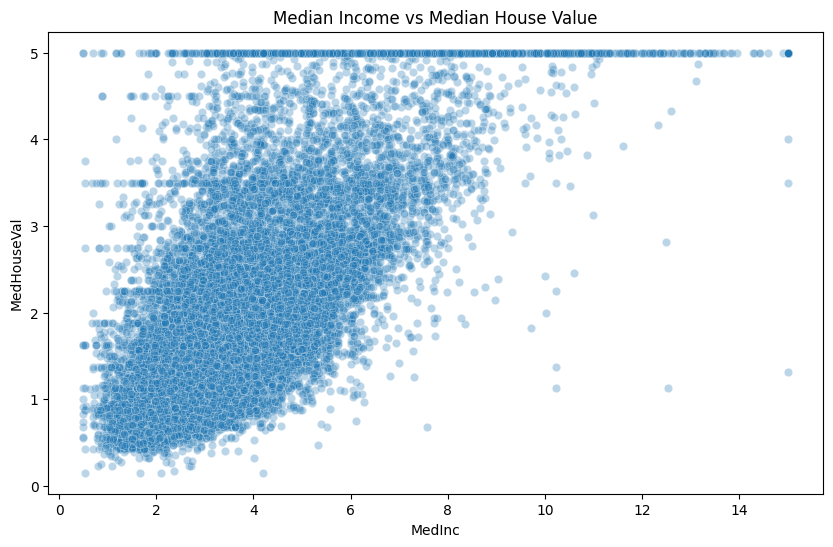

In [129]:
# Visualize the relationship between Median Income and House Value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.3)
plt.title('Median Income vs Median House Value')
plt.show()

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [131]:
# Identify features and target for regression
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [132]:
# Corrected the order of variables returned by train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=34)

# Pipeline

In [133]:
# Define feature groups for the Housing dataset
numeric_features = X.columns.tolist()
print(f"Features to be processed: {numeric_features}")

Features to be processed: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [134]:
from sklearn.linear_model import LinearRegression

# Pipeline for scaling and regression
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

processor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', processor),
    ('regressor', LinearRegression())
])

# Fit the regression model
full_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveBedrms',
                                                   'Population', 'AveOccup',
                                                   'Latitude',
                                                   'Longitude'])])),
                ('regressor', LinearRegression())])

In [135]:
# Evaluate the model
r2_score = full_pipeline.score(x_test, y_test)
print(f"R^2 Score on Test Set: {r2_score:.4f}")

R^2 Score on Test Set: 0.6235


### Observation: Linear Regression on Housing Data
The model achieves an R² score (coefficient of determination). Unlike the Titanic classification problem, here we are predicting a continuous value (price). The closer the score is to 1.0, the better our 'Line of Best Fit' captures the variance in housing prices.

In [136]:
### Final Prediction Example
We can now use our fitted pipeline to predict the value of a house based on its features.

In [137]:
# Predict on the first few rows of the test set
sample_input = x_test.iloc[:5]
predictions = full_pipeline.predict(sample_input)

comparison = pd.DataFrame({'Actual': y_test.iloc[:5].values, 'Predicted': predictions})
display(comparison)

,Actual,Predicted
0,1.714,1.789503
1,0.869,1.567664
2,2.145,2.215264
3,4.908,3.868560
4,3.000,2.280472


This concludes our end-to-end guide on Linear Regression and Gradient Descent!